In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("smartphone_data.csv")

In [16]:
df.sample(5)

,brand,model_name,os,price_inr,launch_year,5g_support,dual_sim,expandable_storage,water_resistance,wireless_charging,...,display_size_inch,display_type,refresh_rate_hz,battery_mah,fast_charging_w,rear_camera_mp,front_camera_mp,camera_setup,weight_g,thickness_mm
507711,Apple,Apple_7690,iOS,94496,2021,1,1,0,0,0,...,6.03,LCD,144,3725,18,108,50,"Ultra-Wide, Macro, Telephoto, Depth",178.9,9.01
479667,Xiaomi,Xiaomi_2059,Android,12921,2025,0,0,1,0,1,...,5.82,OLED,90,4846,25,48,50,"Wide, Telephoto, Ultra-Wide",164.1,8.23
125495,Apple,Apple_7225,iOS,102149,2019,1,1,0,0,0,...,6.49,OLED,120,2842,33,108,50,Telephoto,182.9,7.78
858075,Samsung,Samsung_6753,Android,33998,2020,1,1,1,1,0,...,5.52,LCD,60,5011,100,108,32,Telephoto,182.1,7.85
645808,Nothing,Nothing_4846,Android,28551,2021,1,1,1,1,0,...,6.87,AMOLED,60,4923,18,50,50,"Wide, Depth, Macro",209.8,9.06


In [25]:
df.shape

(1000000, 33)

In [27]:
df.columns

Index(['brand', 'model_name', 'os', 'price_inr', 'launch_year', '5g_support',
       'dual_sim', 'expandable_storage', 'water_resistance',
       'wireless_charging', 'fingerprint_sensor', 'face_unlock', 'gpu_score',
       'cpu_score', 'screen_to_body_ratio', 'build_material',
       'colors_available', 'warranty_years', 'bluetooth_version',
       'wifi_version', 'chipset', 'ram_gb', 'storage_gb', 'display_size_inch',
       'display_type', 'refresh_rate_hz', 'battery_mah', 'fast_charging_w',
       'rear_camera_mp', 'front_camera_mp', 'camera_setup', 'weight_g',
       'thickness_mm'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 33 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   brand                 1000000 non-null  object 
 1   model_name            1000000 non-null  object 
 2   os                    1000000 non-null  object 
 3   price_inr             1000000 non-null  int64  
 4   launch_year           1000000 non-null  int64  
 5   5g_support            1000000 non-null  int64  
 6   dual_sim              1000000 non-null  int64  
 7   expandable_storage    1000000 non-null  int64  
 8   water_resistance      1000000 non-null  int64  
 9   wireless_charging     1000000 non-null  int64  
 10  fingerprint_sensor    1000000 non-null  int64  
 11  face_unlock           1000000 non-null  int64  
 12  gpu_score             1000000 non-null  int64  
 13  cpu_score             1000000 non-null  int64  
 14  screen_to_body_ratio  1000000 non-n

In [29]:
df.describe()

,price_inr,launch_year,5g_support,dual_sim,expandable_storage,water_resistance,wireless_charging,fingerprint_sensor,face_unlock,gpu_score,...,ram_gb,storage_gb,display_size_inch,refresh_rate_hz,battery_mah,fast_charging_w,rear_camera_mp,front_camera_mp,weight_g,thickness_mm
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,...,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,38356.444712,2021.499719,0.699994,0.799755,0.449905,0.400295,0.301262,0.900034,0.700362,3834.638497,...,8.471235,173.000000,6.200263,95.557614,4850.461751,41.691457,76.749216,26.515368,190.026785,8.248653
std,25017.067738,2.291999,0.458260,0.400184,0.497484,0.489958,0.458807,0.299955,0.458100,2550.426715,...,3.702394,131.573641,0.404155,29.630234,887.296206,24.614726,47.229503,16.101968,20.014354,0.721087
min,5000.000000,2018.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1283.000000,...,3.000000,64.000000,5.500000,60.000000,1149.000000,18.000000,13.000000,8.000000,97.900000,7.000000
25%,20172.000000,2020.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1991.000000,...,6.000000,64.000000,5.850000,60.000000,4229.000000,25.000000,50.000000,8.000000,176.500000,7.620000
50%,30304.000000,2021.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3096.000000,...,8.000000,128.000000,6.200000,90.000000,4888.000000,33.000000,64.000000,32.000000,190.000000,8.250000
75%,51356.000000,2024.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5169.000000,...,12.000000,256.000000,6.550000,120.000000,5473.000000,45.000000,108.000000,50.000000,203.600000,8.870000
max,165485.000000,2025.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16849.000000,...,16.000000,512.000000,6.900000,144.000000,8543.000000,100.000000,200.000000,50.000000,282.200000,9.500000


In [31]:
df.isnull().sum()

brand                   0
model_name              0
os                      0
price_inr               0
launch_year             0
5g_support              0
dual_sim                0
expandable_storage      0
water_resistance        0
wireless_charging       0
fingerprint_sensor      0
face_unlock             0
gpu_score               0
cpu_score               0
screen_to_body_ratio    0
build_material          0
colors_available        0
warranty_years          0
bluetooth_version       0
wifi_version            0
chipset                 0
ram_gb                  0
storage_gb              0
display_size_inch       0
display_type            0
refresh_rate_hz         0
battery_mah             0
fast_charging_w         0
rear_camera_mp          0
front_camera_mp         0
camera_setup            0
weight_g                0
thickness_mm            0
dtype: int64

In [37]:
df[df.duplicated()]

,brand,model_name,os,price_inr,launch_year,5g_support,dual_sim,expandable_storage,water_resistance,wireless_charging,...,display_size_inch,display_type,refresh_rate_hz,battery_mah,fast_charging_w,rear_camera_mp,front_camera_mp,camera_setup,weight_g,thickness_mm


In [39]:
df.nunique()

brand                       10
model_name               89990
os                           2
price_inr               108967
launch_year                  8
5g_support                   2
dual_sim                     2
expandable_storage           2
water_resistance             2
wireless_charging            2
fingerprint_sensor           2
face_unlock                  2
gpu_score                14109
cpu_score                17040
screen_to_body_ratio      2001
build_material               3
colors_available             6
warranty_years               2
bluetooth_version            5
wifi_version                 3
chipset                      9
ram_gb                       6
storage_gb                   4
display_size_inch          141
display_type                 3
refresh_rate_hz              4
battery_mah               5809
fast_charging_w              6
rear_camera_mp               6
front_camera_mp              4
camera_setup               205
weight_g                  1607
thicknes

In [64]:
df[["brand","os"]].nunique()

brand    10
os        2
dtype: int64

In [76]:
df["brand"].unique()

array(['Google', 'Samsung', 'Realme', 'OnePlus', 'Vivo', 'Nothing',
       'Apple', 'Oppo', 'Motorola', 'Xiaomi'], dtype=object)

In [78]:
df["brand"].nunique()

10

In [107]:
df["brands"].value_counts()

brands
Nothing     100401
Xiaomi      100276
Vivo        100182
Apple       100066
Google      100013
OnePlus      99956
Realme       99949
Motorola     99927
Samsung      99730
Oppo         99500
Name: count, dtype: int64

In [71]:
df.columns = df.columns.str.upper()
df.columns = df.columns.str.lower()

In [3]:
df.rename(columns = {"brand":"brands"}, inplace=True)

In [4]:
df.sort_values(by="brands", inplace=True)
df.reset_index(drop=True, inplace=True)

### Univariate Analysis

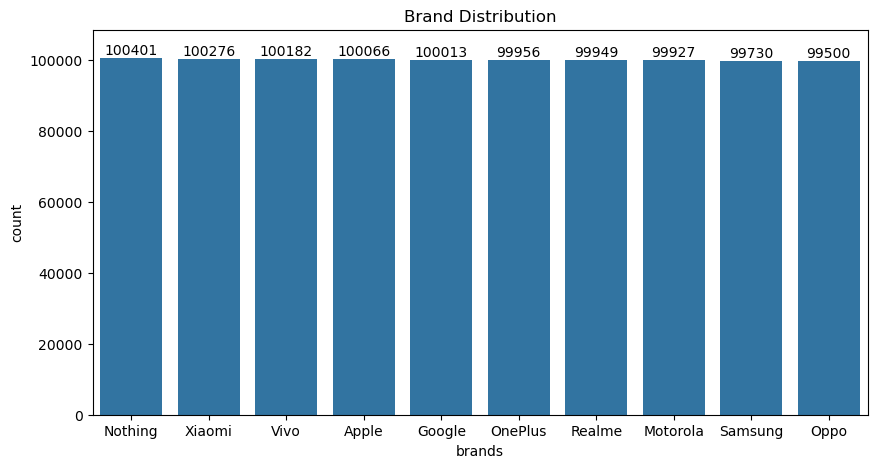

In [174]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x="brands", order=df["brands"].value_counts().index)

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value+1000, int(value), ha="center")

plt.title("Brand Distribution")
plt.ylim(0, max(df["brands"].value_counts()) + 8000)
plt.show()

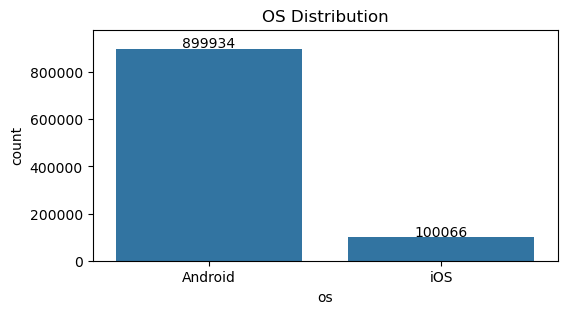

In [186]:
plt.figure(figsize=(6,3))
ax = sns.countplot(data=df, x="os", order=df["os"].value_counts().index)

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value+5000, int(value), ha="center")

plt.title("OS Distribution")
plt.ylim(0, max(df["os"].value_counts()) + 80000)
plt.show()

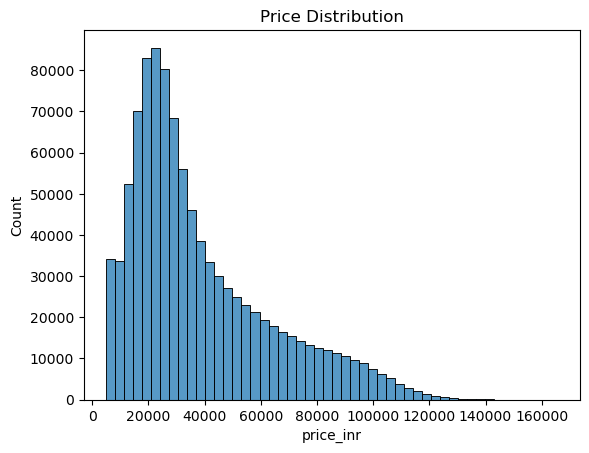

In [192]:
sns.histplot(data=df, x="price_inr", bins=50)
plt.title("Price Distribution")
plt.show()

<Axes: xlabel='price_inr'>

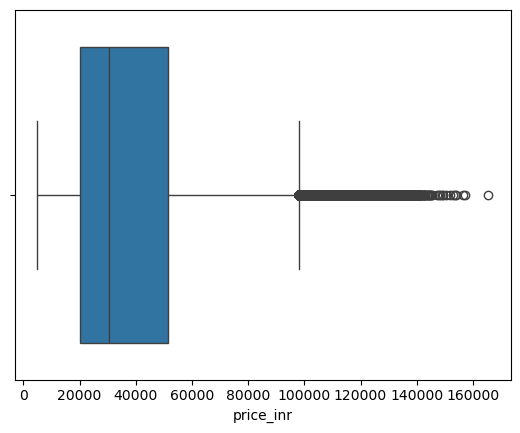

In [200]:
sns.boxplot(data=df, x="price_inr")

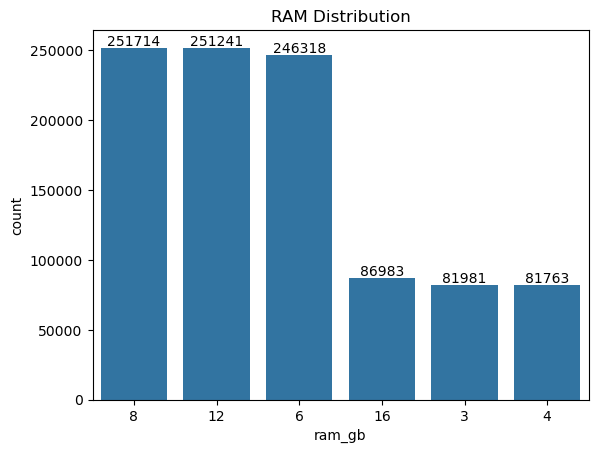

In [214]:
ax = sns.countplot(data=df, x="ram_gb", order=df["ram_gb"].value_counts().index)

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value + 1500, int(value), ha="center")
    
plt.title("RAM Distribution")
plt.show()

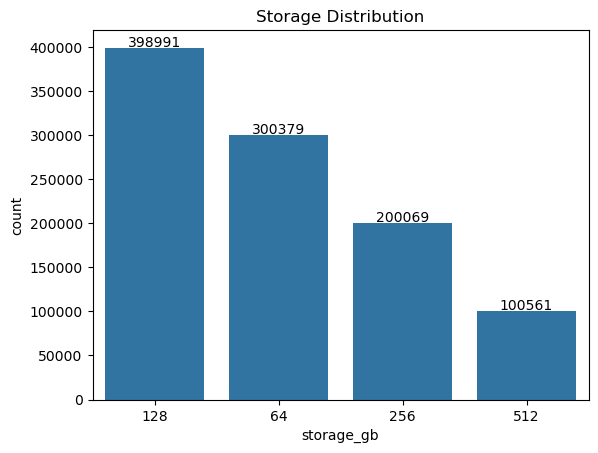

In [216]:
ax = sns.countplot(data=df, x="storage_gb", order=df["storage_gb"].value_counts().index)

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value + 1500, int(value), ha="center")
    
plt.title("Storage Distribution")
plt.show()

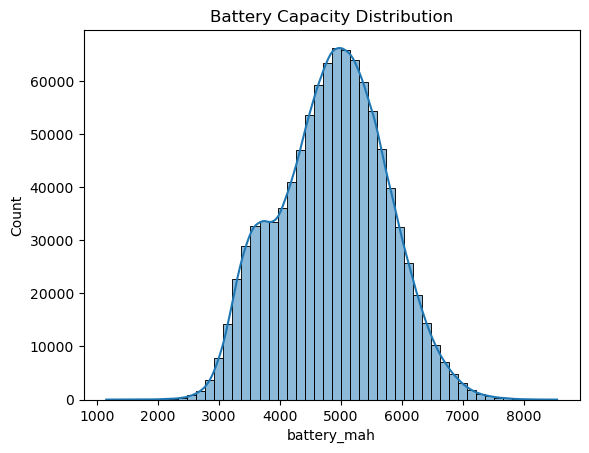

In [222]:
sns.histplot(df["battery_mah"],bins=50, kde=True)
plt.title("Battery Capacity Distribution")
plt.show()

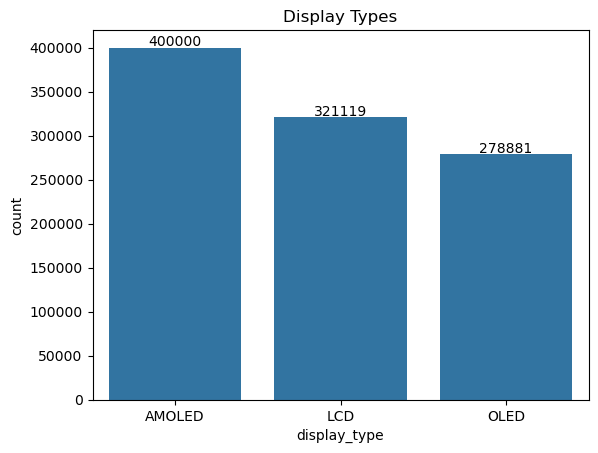

In [231]:
ax = sns.countplot(data=df, x="display_type", order=df["display_type"].value_counts().index)

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value+1900, int(value), ha="center")
    
plt.title("Display Types")
plt.show()

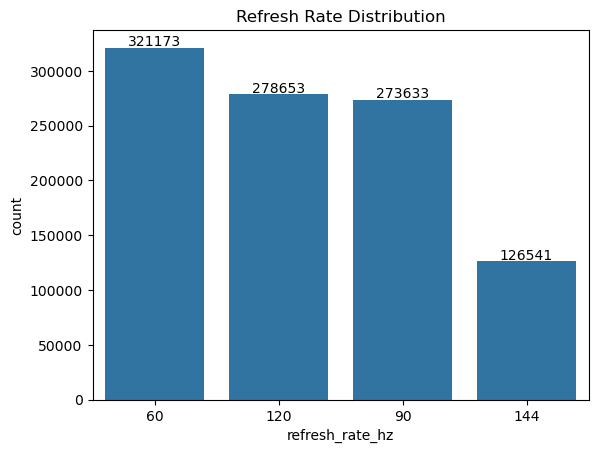

In [242]:
ax = sns.countplot(data=df, x="refresh_rate_hz", order=df["refresh_rate_hz"].value_counts().index)

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value + 1500, int(value), ha="center")
    
plt.title("Refresh Rate Distribution")
plt.show()

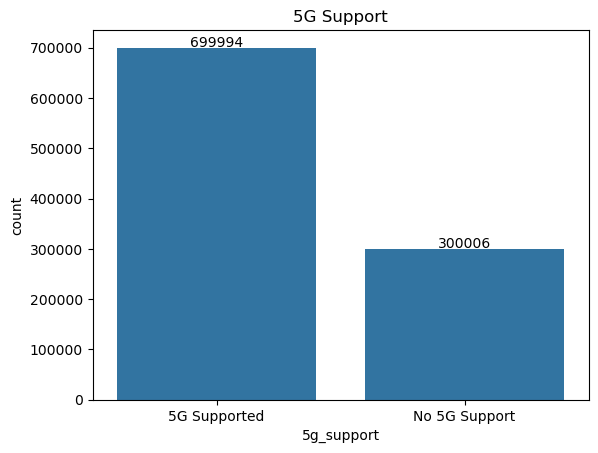

In [251]:
ax = sns.countplot(x=df["5g_support"].map({0: "No 5G Support", 1: "5G Supported"}))

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value + 1500, int(value), ha="center")
    
plt.title("5G Support")
plt.show()

### Bivariate Analysis

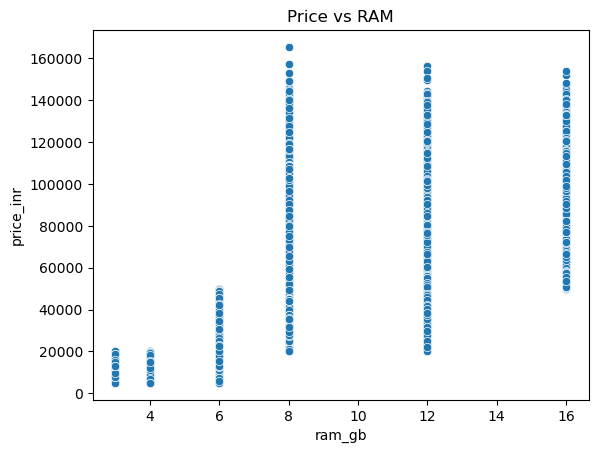

In [262]:
sns.scatterplot(data=df, x="ram_gb", y="price_inr")
plt.title("Price vs RAM")
plt.show()

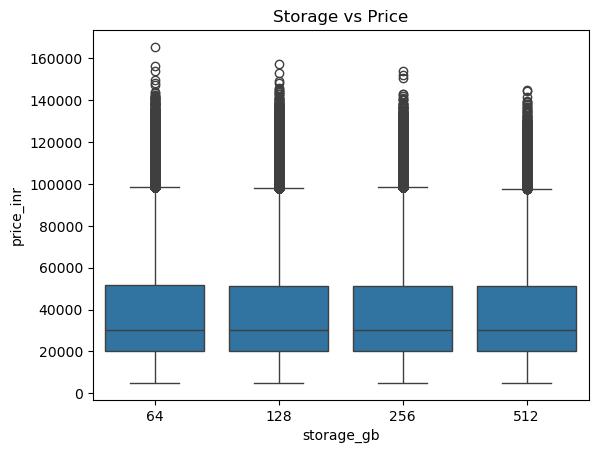

In [264]:
sns.boxplot(data=df, x="storage_gb", y="price_inr")
plt.title("Storage vs Price")
plt.show()

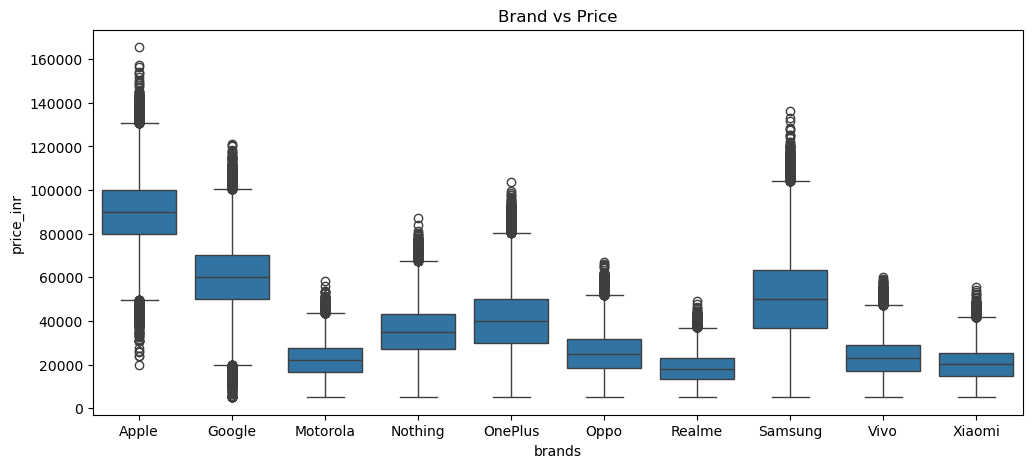

In [270]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df, x='brands', y='price_inr')
plt.title('Brand vs Price')
plt.show()

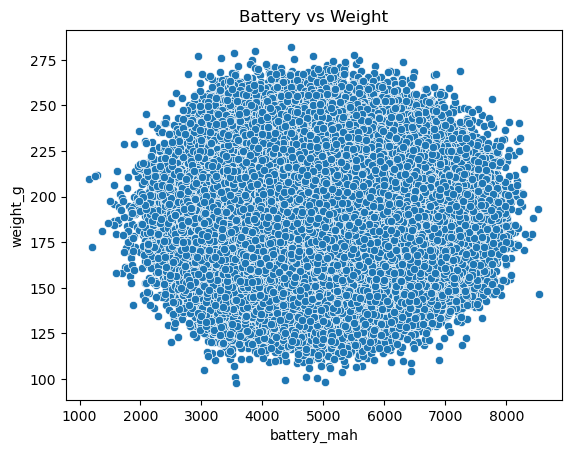

In [101]:
df['battery_mah'].corr(df['weight_g'])

sns.scatterplot(data=df, x="battery_mah", y="weight_g")
plt.title("Battery vs Weight")
plt.show()

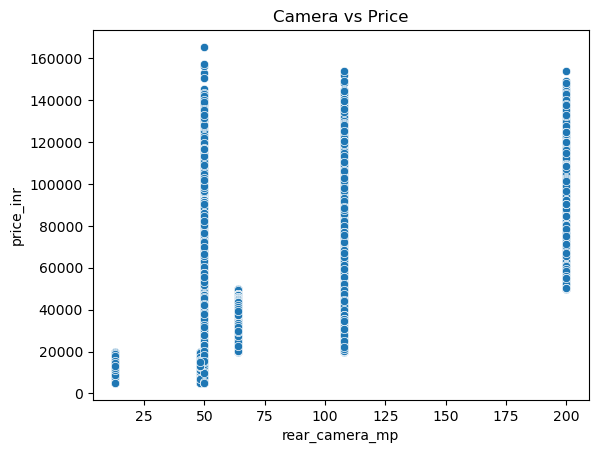

In [274]:
sns.scatterplot(data=df, x="rear_camera_mp", y="price_inr")
plt.title("Camera vs Price")
plt.show()

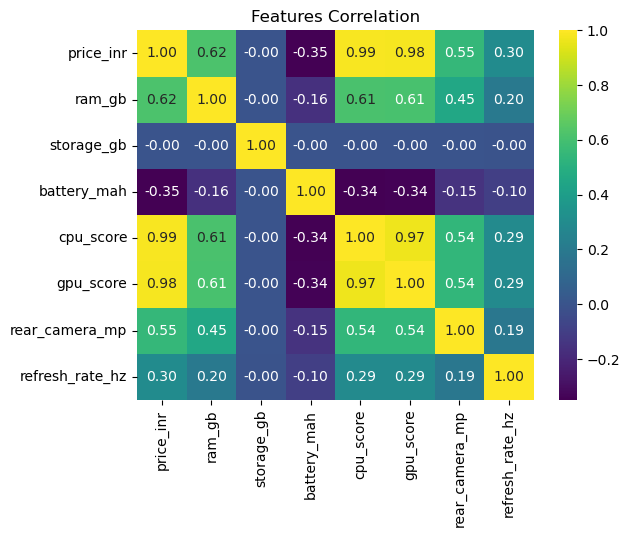

In [23]:
cols = ["price_inr","ram_gb","storage_gb","battery_mah","cpu_score","gpu_score","rear_camera_mp","refresh_rate_hz"]
correlation = df[cols].corr()

sns.heatmap(correlation, annot=True, cmap="viridis", fmt=".2f")

plt.title("Features Correlation")
plt.show()

In [292]:
df.groupby("brands")["price_inr"].mean().round(decimals=0).sort_values(ascending=False)

brands
Apple       90032.0
Google      59990.0
Samsung     50094.0
OnePlus     40002.0
Nothing     35026.0
Oppo        25089.0
Vivo        23063.0
Motorola    22036.0
Xiaomi      20090.0
Realme      18142.0
Name: price_inr, dtype: float64

In [298]:
df.groupby("brands")["battery_mah"].mean().round(decimals=0).sort_values(ascending=False)

brands
Nothing     5005.0
Realme      5005.0
Google      5002.0
Xiaomi      5002.0
Samsung     5001.0
Vivo        5001.0
OnePlus     4998.0
Motorola    4996.0
Oppo        4996.0
Apple       3500.0
Name: battery_mah, dtype: float64

In [300]:
df.groupby("chipset")["cpu_score"].mean().round(decimals=0).sort_values(ascending=False)

chipset
Snapdragon 8 Gen 2    9284.0
Tensor G3             9277.0
A17 Bionic            9271.0
Exynos 1380           3947.0
Snapdragon 778G       3947.0
Dimensity 900         3945.0
Snapdragon 680        1741.0
Helio G85             1738.0
Dimensity 6020        1736.0
Name: cpu_score, dtype: float64

In [310]:
df.groupby("brands")["5g_support"].max()

brands
Apple       1
Google      1
Motorola    1
Nothing     1
OnePlus     1
Oppo        1
Realme      1
Samsung     1
Vivo        1
Xiaomi      1
Name: 5g_support, dtype: int64

In [323]:
df.groupby("brands")["battery_mah"].mean().sort_values(ascending=False)

brands
Nothing     5005.434856
Realme      5004.961630
Google      5001.909802
Xiaomi      5001.503630
Samsung     5000.685762
Vivo        5000.535645
OnePlus     4998.179419
Motorola    4996.036967
Oppo        4995.876472
Apple       3500.435942
Name: battery_mah, dtype: float64

In [327]:
df.groupby('brands')['price_inr'].mean().sort_values(ascending=False)

brands
Apple       90032.242490
Google      59989.899143
Samsung     50093.546175
OnePlus     40001.682890
Nothing     35025.711527
Oppo        25088.843266
Vivo        23063.020872
Motorola    22036.193952
Xiaomi      20089.929116
Realme      18141.918048
Name: price_inr, dtype: float64

In [40]:
df.groupby("brands")["price_category"].agg(lambda x: x.mode())

brands
Apple         Premium
Google        Premium
Motorola    Mid-Range
Nothing     Mid-Range
OnePlus     Mid-Range
Oppo        Mid-Range
Realme      In Budget
Samsung       Premium
Vivo        Mid-Range
Xiaomi      Mid-Range
Name: price_category, dtype: object

### Feature Creation

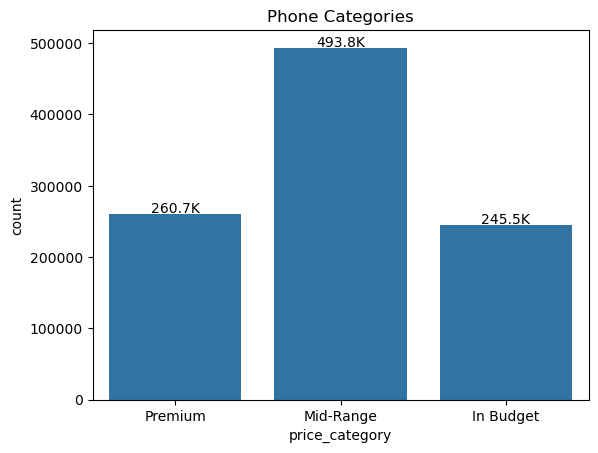

In [248]:
def categorize_price(price):
    if price <= 20000:
        return "In Budget"
    elif price <= 50000:
        return "Mid-Range"
    else:
        return "Premium"

df["price_category"] = df["price_inr"].apply(categorize_price)

ax = sns.countplot(data=df, x="price_category")

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value+2000, f"{int(value)/1000:.1f}K", ha="center")
    
plt.title("Phone Categories")
plt.show()

In [25]:
correlation['price_inr'].sort_values(ascending=False)

price_inr          1.000000
cpu_score          0.987471
gpu_score          0.980607
ram_gb             0.617584
rear_camera_mp     0.546993
refresh_rate_hz    0.295434
storage_gb        -0.000495
battery_mah       -0.349404
Name: price_inr, dtype: float64

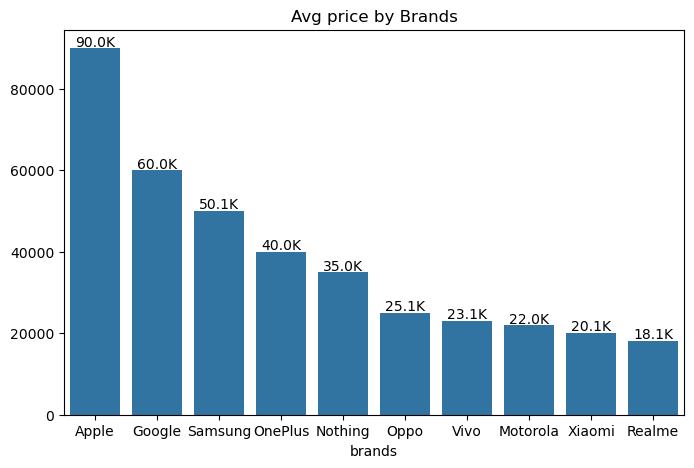

In [242]:
avg_prices = df.groupby("brands")["price_inr"].mean().round(decimals=0).sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=avg_prices.index, y=avg_prices.values)

for i in range(len(ax.patches)):
    value = ax.patches[i].get_height()
    plt.text(i, value+500, f"{int(value)/1000:.1f}K", ha="center")

plt.title("Avg price by Brands")
plt.show()

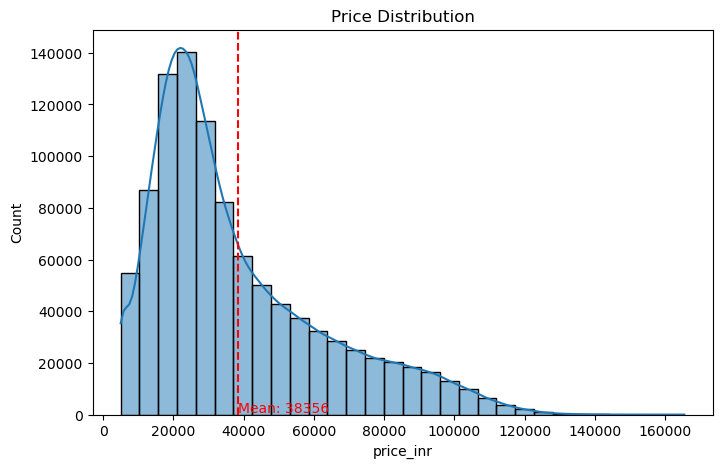

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(df['price_inr'], bins=30, kde=True)

mean_price = df['price_inr'].mean()
plt.axvline(mean_price, linestyle='--', color="red")

plt.text(mean_price, 1000, f'Mean: {mean_price:.0f}', color="red")

plt.title('Price Distribution')
plt.show()

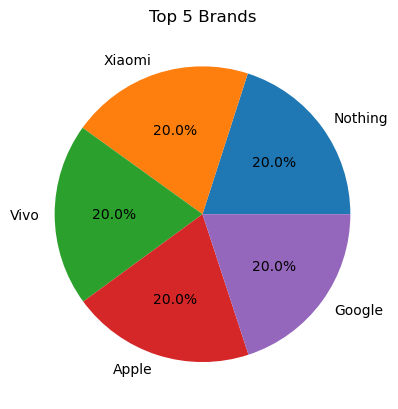

In [87]:
brands = df["brands"].value_counts().head(5)

plt.pie(brands, labels=brands.index, autopct="%1.1f%%")

plt.title("Top 5 Brands")
plt.show()

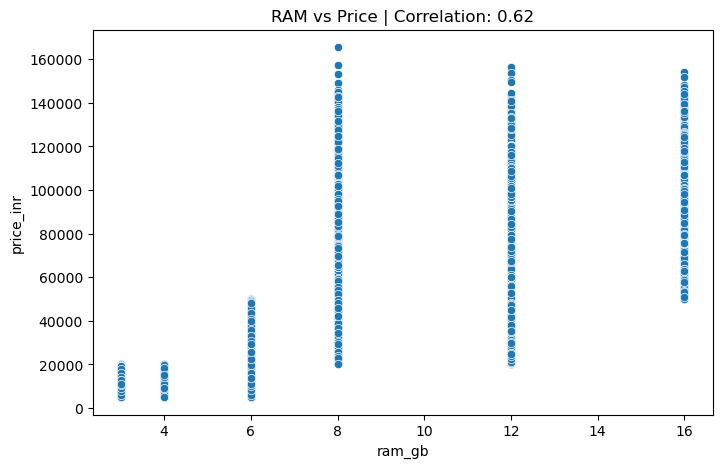

In [89]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='ram_gb', y='price_inr')

corr = df['ram_gb'].corr(df['price_inr'])

plt.title(f'RAM vs Price | Correlation: {corr:.2f}')
plt.show()

In [97]:
df[df["price_inr"]>100000]

,brands,model_name,os,price_inr,launch_year,5g_support,dual_sim,expandable_storage,water_resistance,wireless_charging,...,display_type,refresh_rate_hz,battery_mah,fast_charging_w,rear_camera_mp,front_camera_mp,camera_setup,weight_g,thickness_mm,price_category
4,Apple,Apple_2525,iOS,131579,2019,1,1,0,0,0,...,AMOLED,60,3496,18,200,16,"Macro, Telephoto, Wide",176.8,8.44,Premium
5,Apple,Apple_2106,iOS,100064,2021,1,1,0,0,1,...,LCD,120,3819,18,108,32,"Macro, Wide, Ultra-Wide",218.9,8.74,Premium
6,Apple,Apple_9067,iOS,104815,2020,0,0,0,0,0,...,OLED,120,4144,33,50,50,Ultra-Wide,193.1,8.98,Premium
11,Apple,Apple_4032,iOS,114464,2018,1,1,0,1,0,...,AMOLED,120,3341,18,200,8,"Macro, Telephoto, Ultra-Wide, Wide",157.0,7.13,Premium
14,Apple,Apple_2878,iOS,109105,2024,1,1,0,1,0,...,OLED,120,3671,33,50,16,"Depth, Wide",175.3,8.95,Premium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
798428,Samsung,Samsung_3564,Android,107023,2018,1,1,1,1,0,...,OLED,60,5294,25,200,32,"Depth, Telephoto",211.2,8.68,Premium
798710,Samsung,Samsung_9194,Android,106713,2021,1,0,1,1,1,...,OLED,120,6066,45,200,8,"Macro, Ultra-Wide",173.0,7.10,Premium
799043,Samsung,Samsung_7740,Android,100664,2019,0,1,1,0,0,...,OLED,120,5001,18,108,50,"Ultra-Wide, Macro, Depth",169.1,9.38,Premium
799221,Samsung,Samsung_5443,Android,108713,2025,0,0,0,0,1,...,LCD,120,4127,45,200,32,"Telephoto, Macro",185.9,8.60,Premium


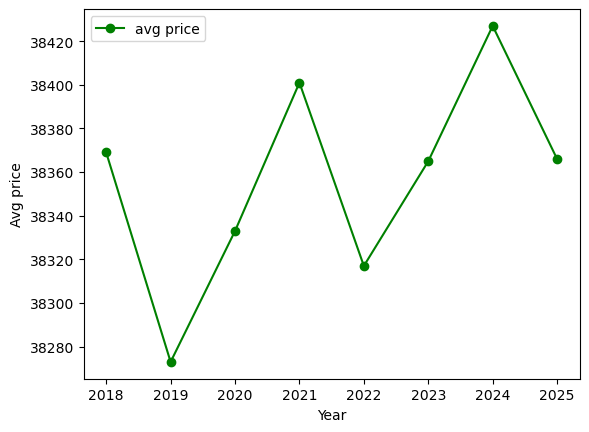

In [127]:
data = df.groupby("launch_year")["price_inr"].mean().round(decimals=0)

plt.plot(data.index, data.values, "o-g", label="avg price")

plt.xlabel("Year")
plt.ylabel("Avg price")
plt.legend(loc="upper left")
plt.show()

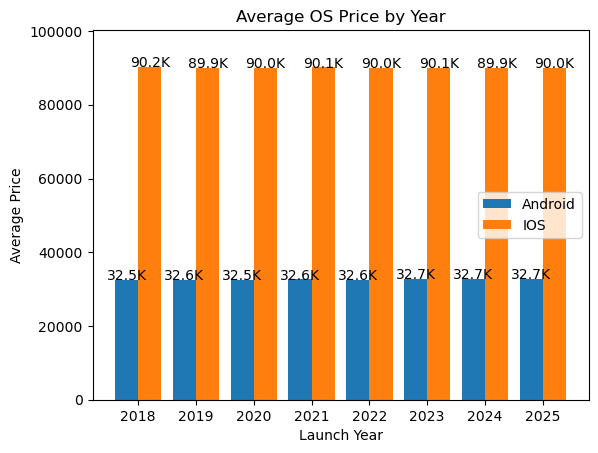

In [20]:
avg_prices = df.groupby(["launch_year","os"])["price_inr"].mean().unstack()

years = avg_prices.index
android_price = avg_prices["Android"]
ios_price = avg_prices["iOS"]

x = np.arange(len(years))
width = 0.4

plt.bar(x-width/2, android_price, width, label="Android")
plt.bar(x+width/2, ios_price, width, label="IOS")

for i in range(len(x)):
    plt.text(x[i]-width/2, android_price.iloc[i] + 20, f"{android_price.iloc[i]/1000:.1f}K", ha="center")
    plt.text(x[i]+width/2, ios_price.iloc[i] + 20, f"{ios_price.iloc[i]/1000:.1f}K", ha="center")

max_value = max(max(android_price), max(ios_price))
plt.ylim(0, max_value + 10050)

plt.xlabel("Launch Year")
plt.ylabel("Average Price")
plt.title("Average OS Price by Year")

plt.xticks(x, years)

plt.legend()
plt.show()

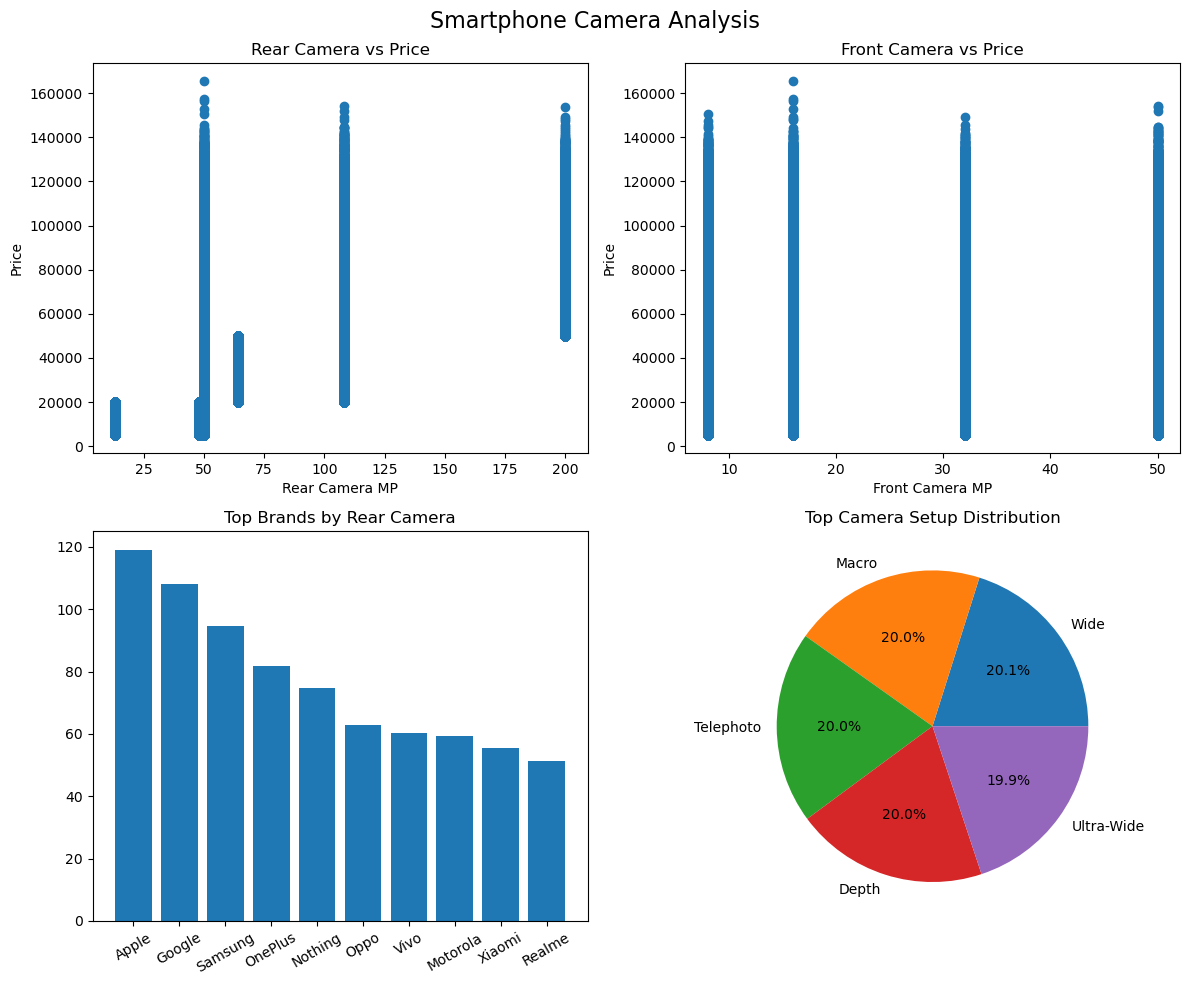

In [60]:
top_brands = df["brands"].value_counts().head(4).index

fig,axes = plt.subplots(2,2, figsize=(12,10))

axes[0,0].scatter(df["rear_camera_mp"], df["price_inr"])
axes[0,0].set_title("Rear Camera vs Price")
axes[0,0].set_xlabel("Rear Camera MP")
axes[0,0].set_ylabel("Price")

axes[0,1].scatter(df["front_camera_mp"], df["price_inr"])
axes[0,1].set_title("Front Camera vs Price")
axes[0,1].set_xlabel("Front Camera MP")
axes[0,1].set_ylabel("Price")

avg_camera = df.groupby("brands")["rear_camera_mp"].mean().sort_values(ascending=False)
axes[1,0].bar(avg_camera.index, avg_camera.values)
axes[1,0].set_title("Top Brands by Rear Camera")
axes[1,0].tick_params(axis='x', rotation=30)

camera_counts = df["camera_setup"].value_counts().head(5)
axes[1,1].pie(camera_counts, labels=camera_counts.index, autopct="%1.1f%%")
axes[1,1].set_title("Top Camera Setup Distribution")

fig.suptitle("Smartphone Camera Analysis", fontsize=16)
fig.tight_layout()
plt.show()